# UTS 2026 - Analisis Dataset Transaksi Ritel

**NIM:** 12221947  
**Produk untuk visualisasi:** Beras Pulen 5 kg

Notebook ini berisi jawaban Soal A dan Soal B:
1. Penggabungan dataset dan jumlah baris.
2. Removing outliers pada kolom harga.
3. Checking missing value.
4. Checking duplikasi dan deduplikasi.
5. Visualisasi line chart penjualan produk bulan 1 sampai bulan 12.


In [ ]:
# Import library
import pandas as pd
import matplotlib.pyplot as plt

# Agar grafik tampil di notebook
%matplotlib inline

## Soal A.1 - Penggabungan Dataset dan Jumlah Seluruh Baris Data

In [ ]:
import pandas as pd

# Membaca dataset dari Google Drive (pastikan path-nya benar)
mgl = pd.read_csv('/content/transaksi_ritel_mgl.csv')
yk = pd.read_csv('/content/transaksi_ritel_yk.csv')

# Menggabungkan dataset MGL dan YK
gabung = pd.concat([mgl, yk], ignore_index=True)

# Menampilkan jumlah baris dan kolom
print("Jumlah baris dataset MGL:", len(mgl))
print("Jumlah baris dataset YK :", len(yk))
print("Jumlah seluruh baris setelah digabung:", len(gabung))
print("Jumlah kolom:", gabung.shape[1])

# Menampilkan 5 data pertama
gabung.head()

**Hasil:**  
Jumlah seluruh baris data setelah dataset digabung adalah **23.849 baris**.

## Soal A.2 - Removing Outliers pada Kolom Harga

Metode yang digunakan adalah **IQR (Interquartile Range)**.

Rumus:
- Q1 = kuartil 25%
- Q3 = kuartil 75%
- IQR = Q3 - Q1
- Batas bawah = Q1 - 1.5 × IQR
- Batas atas = Q3 + 1.5 × IQR


In [ ]:
# Menghitung Q1, Q3, dan IQR pada kolom harga
Q1 = gabung['harga'].quantile(0.25)
Q3 = gabung['harga'].quantile(0.75)
IQR = Q3 - Q1

# Menentukan batas bawah dan batas atas
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Mencari data outlier
outlier = gabung[(gabung['harga'] < lower) | (gabung['harga'] > upper)]

# Menghapus outlier
data_tanpa_outlier = gabung[(gabung['harga'] >= lower) & (gabung['harga'] <= upper)]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Batas bawah:", lower)
print("Batas atas:", upper)
print("Jumlah outlier pada kolom harga:", len(outlier))
print("Jumlah data setelah removing outlier:", len(data_tanpa_outlier))

**Hasil:**  
Jumlah outlier pada kolom harga adalah **2.394 data**.  
Jumlah data setelah outlier dihapus adalah **21.349 data**.

## Soal A.3 - Checking Missing Value Data

In [ ]:
# Mengecek jumlah missing value pada setiap kolom
missing_value = gabung.isnull().sum()

print("Jumlah missing value tiap kolom:")
print(missing_value)

print("\nTotal seluruh missing value:", missing_value.sum())

**Hasil missing value:**

| Kolom | Jumlah Missing Value |
|---|---:|
| tanggal | 40 |
| kode | 37 |
| nama | 108 |
| jumlah | 107 |
| harga | 106 |
| area | 0 |

Total seluruh missing value adalah **398 data**.

## Soal A.4 - Checking Duplikasi dan Deduplikasi Dataset

In [ ]:
# Mengecek data duplikat
jumlah_duplikat = gabung.duplicated().sum()

# Melakukan deduplikasi
data_dedup = gabung.drop_duplicates()

print("Jumlah data duplikat:", jumlah_duplikat)
print("Jumlah data sebelum deduplikasi:", len(gabung))
print("Jumlah data setelah deduplikasi:", len(data_dedup))

# Soal B - Visualisasi Line Chart Penjualan Produk

Produk sesuai NIM **12221947** adalah **Beras Pulen 5 kg**.  
Visualisasi dibuat berdasarkan transaksi bulan 1 sampai bulan 12.


In [ ]:
# Mengubah kolom tanggal menjadi format datetime
gabung['tanggal'] = pd.to_datetime(gabung['tanggal'], dayfirst=True, errors='coerce')

# Membuat kolom bulan dari tanggal transaksi
gabung['bulan'] = gabung['tanggal'].dt.month

# Filter data produk Beras Pulen 5 kg
produk = 'Beras Pulen 5 kg'
data_produk = gabung[gabung['nama'] == produk]

# Menghitung total penjualan berdasarkan kolom jumlah per bulan
penjualan_bulanan = data_produk.groupby('bulan')['jumlah'].sum().reindex(range(1, 13), fill_value=0)

# Menampilkan hasil penjualan bulanan
penjualan_bulanan

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

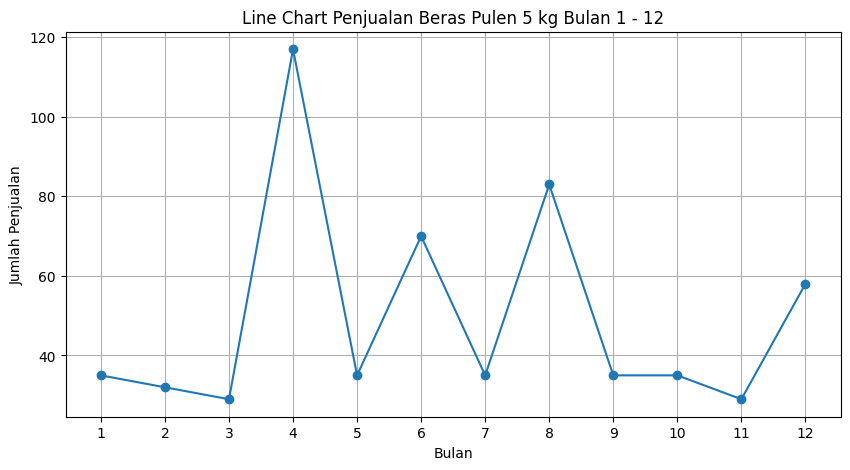

In [26]:
# Membuat line chart penjualan produk bulan 1 sampai 12
plt.figure(figsize=(10, 5))
plt.plot(penjualan_bulanan.index, penjualan_bulanan.values, marker='o')

plt.title('Line Chart Penjualan Beras Pulen 5 kg Bulan 1 - 12')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Penjualan')
plt.xticks(range(1, 13))
plt.grid(True)

plt.show()

## Hasil Penjualan Produk Beras Pulen 5 kg per Bulan

| Bulan | Jumlah Penjualan |
|---|---:|
| 1 | 35 |
| 2 | 32 |
| 3 | 29 |
| 4 | 117 |
| 5 | 35 |
| 6 | 70 |
| 7 | 35 |
| 8 | 83 |
| 9 | 35 |
| 10 | 35 |
| 11 | 29 |
| 12 | 58 |

## Kesimpulan

1. Dataset MGL dan YK berhasil digabungkan menggunakan `pd.concat()`.
2. Jumlah seluruh baris setelah penggabungan adalah **23.849 baris**.
3. Missing value yang ditemukan berjumlah **398 data**.
4. Data duplikat yang ditemukan berjumlah **7.502 data**.
5. Outlier pada kolom harga yang ditemukan dengan metode IQR berjumlah **2.394 data**.
6. Produk **Beras Pulen 5 kg** memiliki penjualan tertinggi pada bulan ke-4, yaitu **117**.
